In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Single Model

## Undersampling

avalia qual metodo de undersamplig teve o melhor resultado

### Accuracy

In [20]:
single_model = "LGBMClassifier"

In [36]:

acc = pd.read_json("../models/single_model/tables/accuracy_score.jsonl",
             lines=True,
             orient="records")
acc['timestamp'] = pd.to_datetime(acc['timestamp']).dt.floor('min')
acc.set_index("timestamp", inplace=True)
acc.sort_values(by=['score'], inplace=True)
acc.fillna({'undersampling':'NA'}, inplace=True)

In [27]:
acc

,model_name,dataset,metric_name,score,undersampling
timestamp,,,,,
2026-04-15 17:56:00,RandomForestClassifier,validation,accuracy_score,0.474860,NearMissV3
2026-04-17 16:51:00,LogisticRegression,train,accuracy_score,0.509831,NearMissV3
2026-04-15 17:56:00,RandomForestClassifier,train,accuracy_score,0.512640,NearMissV3
2026-04-17 19:18:00,LGBMClassifier,validation,accuracy_score,0.513966,NearMissV3
2026-04-17 16:51:00,LogisticRegression,validation,accuracy_score,0.525140,NearMissV3
...,...,...,...,...,...
2026-04-15 19:02:00,RandomForestClassifier,train,accuracy_score,0.845506,OneSidedSelection
2026-04-15 17:45:00,RandomForestClassifier,train,accuracy_score,0.855337,TomekLinks
2026-04-17 17:59:00,LGBMClassifier,train,accuracy_score,0.856742,OneSidedSelection


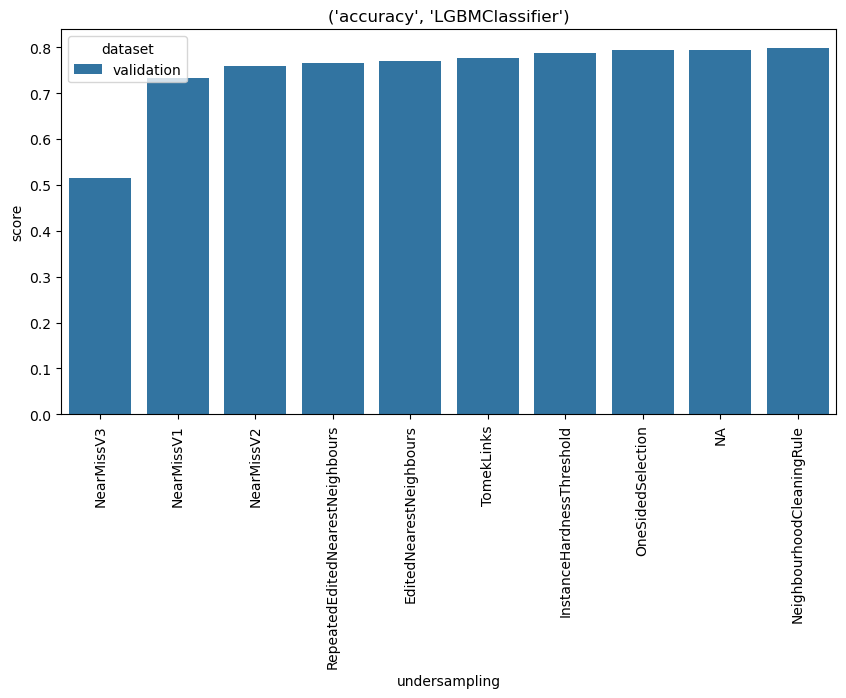

In [28]:
plt.figure(figsize=(10,5))
sns.barplot(
    data=acc.loc[(acc['model_name']==single_model) & (acc['dataset']=='validation')],
    x='undersampling',
    y='score',
    hue='dataset'    
)
plt.title(f'{"accuracy", single_model}')
plt.xticks(rotation=90)
plt.show()

### Roc auc

In [33]:
rocauc = pd.read_json("../models/single_model/tables/roc_auc_score.jsonl",
             lines=True,
             orient="records")
rocauc['timestamp'] = pd.to_datetime(rocauc['timestamp']).dt.floor('min')
rocauc.set_index("timestamp", inplace=True)
rocauc.sort_values(by=['score'], inplace=True)
rocauc.fillna({'undersampling':'NA'}, inplace=True)

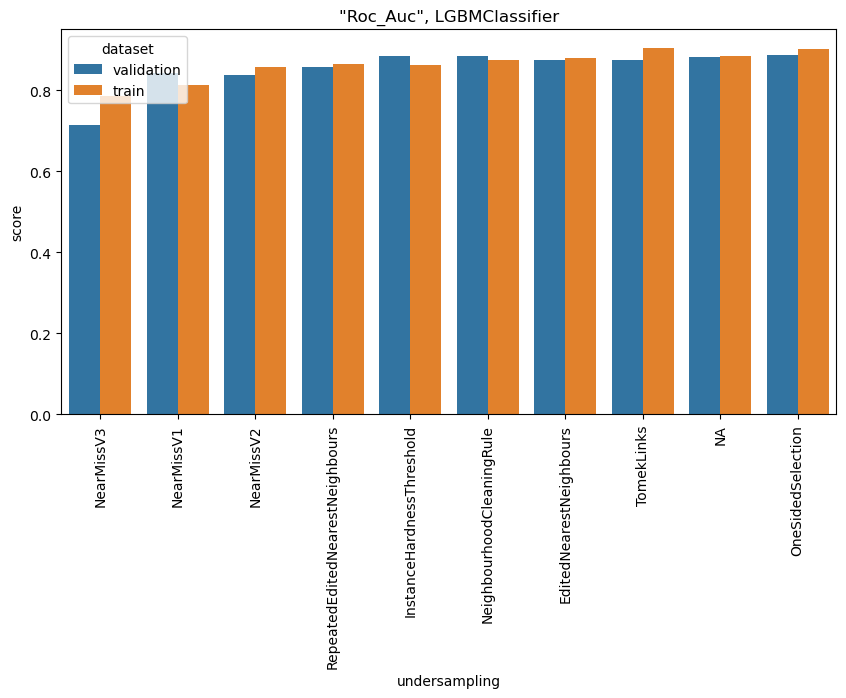

In [32]:
plt.figure(figsize=(10,5))
sns.barplot(
    data=rocauc.loc[rocauc['model_name']==single_model],
    x='undersampling',
    y='score',
    hue='dataset'    
)
plt.title(f'"Roc_Auc", {single_model}')
plt.xticks(rotation=90)
plt.show()

### F1

In [37]:
f1 = pd.read_json("../models/single_model/tables/f1_score.jsonl",
             lines=True,
             orient="records")
f1['timestamp'] = pd.to_datetime(f1['timestamp']).dt.floor('min')
f1.set_index("timestamp", inplace=True)
f1.sort_values(by=['score'], inplace=True)
f1.fillna({'undersampling':'NA'}, inplace=True)

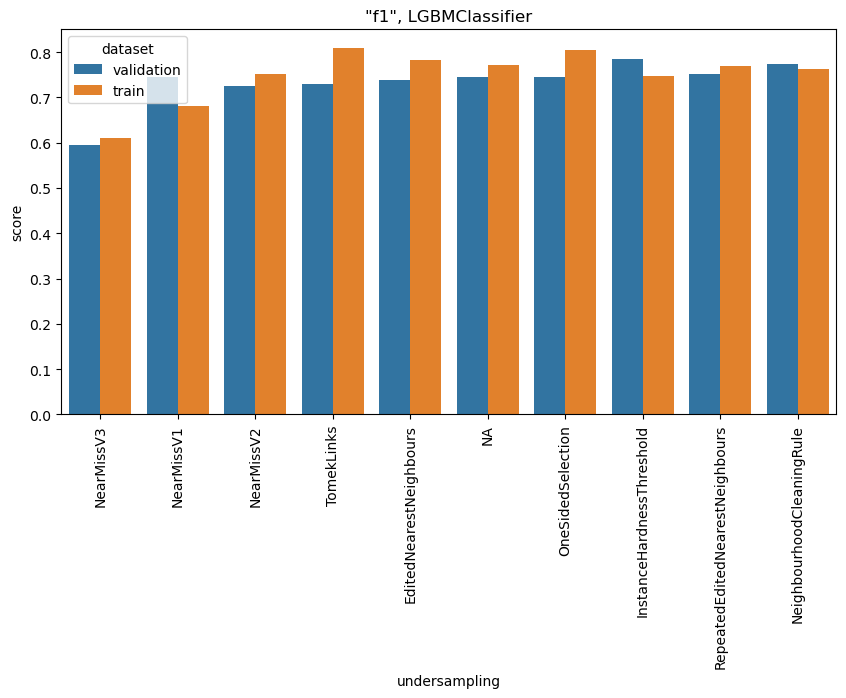

In [38]:
plt.figure(figsize=(10,5))
sns.barplot(
    data=f1.loc[f1['model_name']==single_model],
    x='undersampling',
    y='score',
    hue='dataset'    
)
plt.title(f'"f1", {single_model}')
plt.xticks(rotation=90)
plt.show()

## Model

In [39]:
data = '2026-04'
undersamplig='NA'
dataset = 'validation'

In [40]:
tmp = (acc
 .loc[(data)]
 .loc[
     (acc['model_name']==single_model) & 
     (acc['undersampling']==undersamplig) & 
     (acc['dataset']==dataset)]
 .sort_index()
 .reset_index()
 )

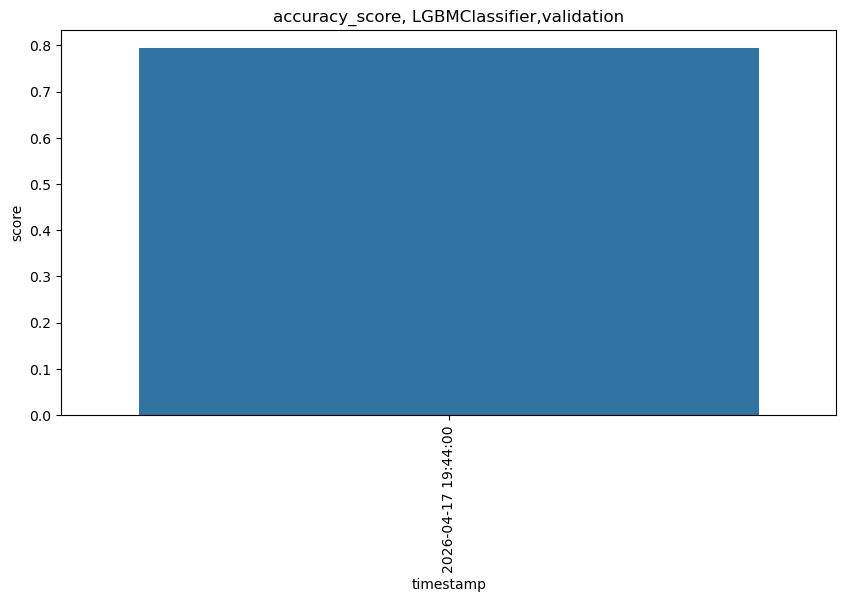

In [41]:
plt.figure(figsize=(10,5))
sns.barplot(
    data=tmp,
    x='timestamp',
    y='score',
    # hue='dataset',
    # palette={'train': 'royalblue', 'validation': 'tomato'}
)
plt.title(
    f'{tmp['metric_name'].unique()[0]}, {tmp['model_name'].unique()[0]},{tmp['dataset'].unique()[0]}')
plt.xticks(rotation=90)
plt.show()

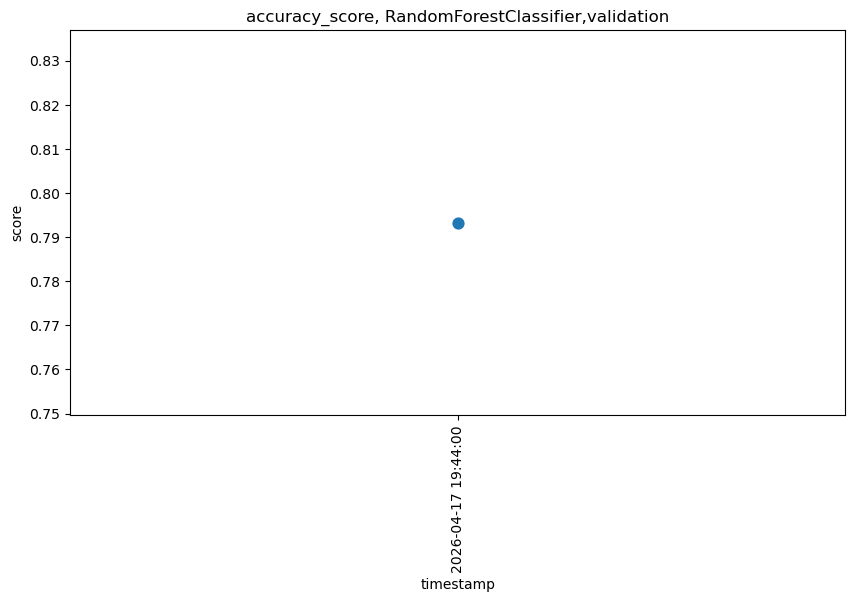

In [42]:
plt.figure(figsize=(10,5))
sns.pointplot(
    data=tmp,
    x='timestamp',
    y='score',
    # hue='dataset',
    # palette={'train': 'royalblue', 'validation': 'tomato'}
)
plt.title(
    f'{acc['metric_name'].unique()[0]}, {acc['model_name'].unique()[0]},{acc['dataset'].unique()[0]}')
plt.xticks(rotation=90)
plt.show()

# ANN

In [ ]:
acc_ann = pd.read_json("../models/ann_model/tables/accuracy_score.jsonl",
             lines=True,
             orient="records")
acc_ann['timestamp'] = pd.to_datetime(acc_ann['timestamp']).dt.floor('min')
acc_ann.set_index("timestamp", inplace=True)
# acc_ann.sort_values(by=['score'], inplace=True)

In [ ]:
plt.figure(figsize=(10,5))
sns.barplot(
    data=acc_ann,
    x='timestamp',
    y='score',
    hue='dataset'   
)
plt.title('ANN')
plt.xticks(rotation=90)
plt.show()

In [ ]:
clfrpt_ann = pd.read_json("../models/ann_model/tables/classification_report.jsonl",
             lines=True,
             orient="records")
clfrpt_ann['timestamp'] = pd.to_datetime(clfrpt_ann['timestamp']).dt.floor('min')
tmp=pd.json_normalize(clfrpt_ann['report'])
clfrpt_ann = pd.concat([clfrpt_ann, tmp], axis=1)
clfrpt_ann.drop(columns=['report'], inplace=True)

In [ ]:
plt.figure(figsize=(10,5))
sns.pointplot(
    data=clfrpt_ann,
    x='timestamp',
    y='1.f1-score',
    legend=True,
    label=1,

)
sns.pointplot(
    data=clfrpt_ann,
    x='timestamp',
    y='0.f1-score',
    legend=True,
    label=0,

)

plt.xticks(rotation=90)
plt.show()